In [1]:
# Load radargrams over David Glacier from KOPRI
# Loads MagLoResInco2 from KPDC which hopefully still has phase info.

from impdar.lib import load, plot 
import os

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

import cartopy.crs as ccrs

import segyio
import shapefile
import shapely
import xarray as xr

In [7]:
path_MagLoResInco = '/mnt/c/users/ZacharyKatz/Desktop/KPDC/KPDC_David_IPR_2017_0028/2016-2017David/pik1/DVG/IBH0c/GL0328c/'
#path_MagLoResInco = '/mnt/c/users/ZacharyKatz/Desktop/KPDC/KPDC_David_IPR_2017_0028/2016-2017David/pik1/NIS/IBH0c/Y44a/'
file_paths = [os.path.join(path_MagLoResInco, f) for f in os.listdir(path_MagLoResInco) if f.endswith('MagLoResInco2')]
path = file_paths[0]

In [8]:
raw = np.fromfile(path, dtype="<i2")

samples_per_trace=1024
scale=20000
traces = raw.size // samples_per_trace
data = raw[:traces * samples_per_trace].reshape(traces, samples_per_trace)
data = data.astype(np.float32) / scale


In [9]:
raw = np.fromfile(path, dtype='>i2')   # or >f4 if float32
print(raw[:20])

[    1 -4173     1 -1353     1  -156     1 -1002     2  3467     2  4172
     1  -587     2  6922     2 10579     2 11433]


In [10]:
data

array([[ 0.0128 , -0.97365,  0.0128 , ...,  0.39625,  0.0128 ,  0.98505],
       [ 0.0128 ,  0.30665,  0.0128 , ..., -0.6531 ,  0.0128 ,  1.17725],
       [ 0.0128 , -1.2931 ,  0.0128 , ..., -0.78125,  0.0128 ,  1.5484 ],
       ...,
       [ 0.0128 ,  1.2669 ,  0.0128 , ..., -1.1147 ,  0.0128 ,  0.07555],
       [ 0.0128 ,  0.17765,  0.0128 , ...,  0.89585,  0.0128 , -1.28025],
       [ 0.0128 , -0.43555,  0.0128 , ..., -0.4997 ,  0.0128 , -1.29315]],
      shape=(68287, 1024), dtype=float32)

Text(0, 0.5, 'Two-way Travel Time [usec]')

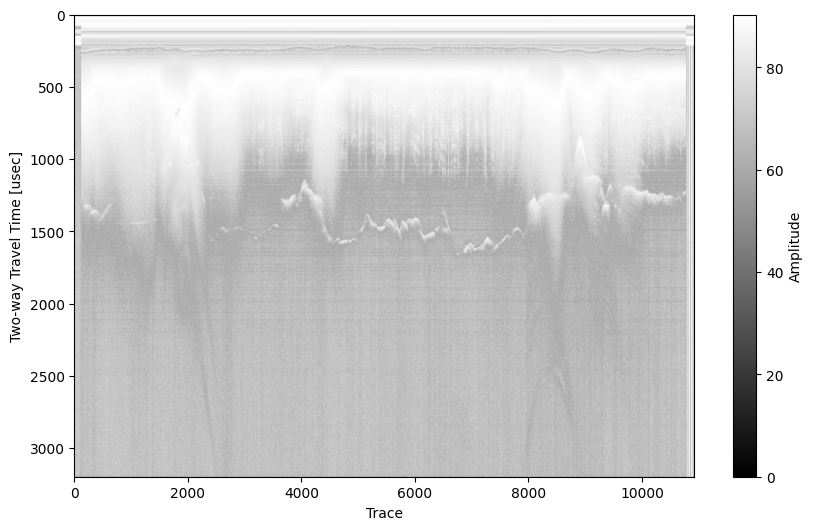

In [11]:
raw = np.fromfile(path, dtype='>i2')

channels = raw[0::2]
amps = raw[1::2]

data = amps.reshape(-1, 3200).astype(float)

radargram = 20*np.log10(np.abs(data) + 1)

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(radargram.T, aspect='auto', cmap='gray')
fig.colorbar(im, ax=ax, label='Amplitude')
ax.set_xlabel('Trace')
ax.set_ylabel('Two-way Travel Time [usec]')